# Stage 4: Hierarchical Clustering & Dendrograms

This notebook uses the Stage 3 distance matrix to discover groups of similar assets and to prepare cluster structure for later hierarchical risk parity analysis.

In [1]:
from pathlib import Path
import os
import sys
import pandas as pd

project_root = Path.cwd().resolve()
while not (project_root / "src").exists() and project_root != project_root.parent:
    project_root = project_root.parent

os.chdir(project_root)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.clustering import (
    compute_linkage_matrix,
    assign_clusters,
    get_cluster_members,
    plot_dendrogram,
)
from src.covariance import compute_correlation_matrix, compute_distance_matrix
from src.data_pipeline import (
    SAMPLE_UNIVERSE,
    DataPreprocessor,
    YahooFinanceProvider,
)

## Load Stage 3 Outputs

The notebook first attempts to load previously saved Stage 3 outputs. If those saved artifacts are unavailable, it falls back to reconstructing Stage 3 data from the pipeline.

In [2]:
stage_3_archive = project_root / "notebooks" / "03_correlation_covariance" / "stage_03_outputs.pkl"
distance_matrix_df = None

if stage_3_archive.exists():
    stage_3_data = pd.read_pickle(stage_3_archive)
    distance_matrix_df = stage_3_data.get("distance_matrix_df")

if distance_matrix_df is None:
    symbols = list(SAMPLE_UNIVERSE)
    provider = YahooFinanceProvider()
    market_data = provider.get_market_data(symbols, "2020-01-01", "2024-12-31")
    prices_df, _data_quality_summary = DataPreprocessor.handle_missing_values(market_data.prices_df)
    stage_2_outputs = DataPreprocessor.build_returns_risk_outputs(prices_df)
    log_returns_df = stage_2_outputs.log_returns_df
    correlation_matrix = compute_correlation_matrix(log_returns_df)
    distance_matrix_df = compute_distance_matrix(correlation_matrix)

distance_matrix_df

asset,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
asset,,,,,,,,,,,,,,,,,,,,,
ASIANPAINT.NS,0.000000,0.587219,0.615160,0.648528,0.615628,0.694575,0.600554,0.584872,0.521285,0.582088,...,0.670917,0.642559,0.569824,0.613229,0.621917,0.545321,0.588844,0.581925,0.531130,0.606025
AXISBANK.NS,0.587219,0.000000,0.568241,0.649781,0.637715,0.697140,0.603943,0.478258,0.595739,0.348618,...,0.578831,0.600976,0.532736,0.422275,0.604527,0.553754,0.585292,0.576749,0.517106,0.590405
BHARTIARTL.NS,0.615160,0.568241,0.000000,0.627679,0.626449,0.707675,0.598715,0.566801,0.616934,0.550404,...,0.599055,0.597750,0.582271,0.568319,0.586017,0.577035,0.596816,0.600192,0.564682,0.611602
CIPLA.NS,0.648528,0.649781,0.627679,0.000000,0.511589,0.668939,0.631632,0.673630,0.641777,0.660655,...,0.658539,0.645014,0.656349,0.661653,0.501144,0.618208,0.627563,0.628070,0.644862,0.630936
DRREDDY.NS,0.615628,0.637715,0.626449,0.511589,0.000000,0.662578,0.598656,0.649670,0.588716,0.644860,...,0.644825,0.639887,0.608805,0.644847,0.527467,0.615199,0.608987,0.593992,0.596972,0.587022
GOLDBEES.NS,0.694575,0.697140,0.707675,0.668939,0.662578,0.000000,0.689311,0.719978,0.690360,0.708617,...,0.691416,0.722331,0.694923,0.731369,0.686983,0.703548,0.685352,0.675807,0.702395,0.679905
HCLTECH.NS,0.600554,0.603943,0.598715,0.631632,0.598656,0.689311,0.000000,0.593118,0.587390,0.591172,...,0.597322,0.633260,0.558971,0.603229,0.593720,0.564607,0.420472,0.420811,0.560400,0.439239
HDFCBANK.NS,0.584872,0.478258,0.566801,0.673630,0.649670,0.719978,0.593118,0.000000,0.614145,0.422323,...,0.626465,0.599046,0.527337,0.485560,0.604599,0.572531,0.584126,0.586962,0.524031,0.591298
HINDUNILVR.NS,0.521285,0.595739,0.616934,0.641777,0.588716,0.690360,0.587390,0.614145,0.000000,0.609908,...,0.666373,0.667730,0.582580,0.635580,0.612146,0.531904,0.583531,0.591757,0.572906,0.596817


## Distance Matrix

Display the Stage 3 distance matrix used for clustering.

In [3]:
display(distance_matrix_df)

asset,ASIANPAINT.NS,AXISBANK.NS,BHARTIARTL.NS,CIPLA.NS,DRREDDY.NS,GOLDBEES.NS,HCLTECH.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,...,ONGC.NS,POWERGRID.NS,RELIANCE.NS,SBIN.NS,SUNPHARMA.NS,TATACONSUM.NS,TCS.NS,TECHM.NS,ULTRACEMCO.NS,WIPRO.NS
asset,,,,,,,,,,,,,,,,,,,,,
ASIANPAINT.NS,0.000000,0.587219,0.615160,0.648528,0.615628,0.694575,0.600554,0.584872,0.521285,0.582088,...,0.670917,0.642559,0.569824,0.613229,0.621917,0.545321,0.588844,0.581925,0.531130,0.606025
AXISBANK.NS,0.587219,0.000000,0.568241,0.649781,0.637715,0.697140,0.603943,0.478258,0.595739,0.348618,...,0.578831,0.600976,0.532736,0.422275,0.604527,0.553754,0.585292,0.576749,0.517106,0.590405
BHARTIARTL.NS,0.615160,0.568241,0.000000,0.627679,0.626449,0.707675,0.598715,0.566801,0.616934,0.550404,...,0.599055,0.597750,0.582271,0.568319,0.586017,0.577035,0.596816,0.600192,0.564682,0.611602
CIPLA.NS,0.648528,0.649781,0.627679,0.000000,0.511589,0.668939,0.631632,0.673630,0.641777,0.660655,...,0.658539,0.645014,0.656349,0.661653,0.501144,0.618208,0.627563,0.628070,0.644862,0.630936
DRREDDY.NS,0.615628,0.637715,0.626449,0.511589,0.000000,0.662578,0.598656,0.649670,0.588716,0.644860,...,0.644825,0.639887,0.608805,0.644847,0.527467,0.615199,0.608987,0.593992,0.596972,0.587022
GOLDBEES.NS,0.694575,0.697140,0.707675,0.668939,0.662578,0.000000,0.689311,0.719978,0.690360,0.708617,...,0.691416,0.722331,0.694923,0.731369,0.686983,0.703548,0.685352,0.675807,0.702395,0.679905
HCLTECH.NS,0.600554,0.603943,0.598715,0.631632,0.598656,0.689311,0.000000,0.593118,0.587390,0.591172,...,0.597322,0.633260,0.558971,0.603229,0.593720,0.564607,0.420472,0.420811,0.560400,0.439239
HDFCBANK.NS,0.584872,0.478258,0.566801,0.673630,0.649670,0.719978,0.593118,0.000000,0.614145,0.422323,...,0.626465,0.599046,0.527337,0.485560,0.604599,0.572531,0.584126,0.586962,0.524031,0.591298
HINDUNILVR.NS,0.521285,0.595739,0.616934,0.641777,0.588716,0.690360,0.587390,0.614145,0.000000,0.609908,...,0.666373,0.667730,0.582580,0.635580,0.612146,0.531904,0.583531,0.591757,0.572906,0.596817


## Compute Linkage Matrix

Compute the hierarchical clustering linkage matrix using the Stage 3 distance matrix.

In [4]:
linkage_ward = compute_linkage_matrix(distance_matrix_df, method="ward")
linkage_average = compute_linkage_matrix(distance_matrix_df, method="average")
linkage_ward[:5]

array([[ 1.        ,  9.        ,  0.3486182 ,  2.        ],
       [10.        , 24.        ,  0.38081315,  2.        ],
       [ 6.        , 29.        ,  0.41532392,  3.        ],
       [21.        , 28.        ,  0.43205591,  3.        ],
       [ 7.        , 12.        ,  0.43726855,  2.        ]])

## Dendrogram Comparison

Compare Ward and average linkage dendrograms to see how cluster structure changes.

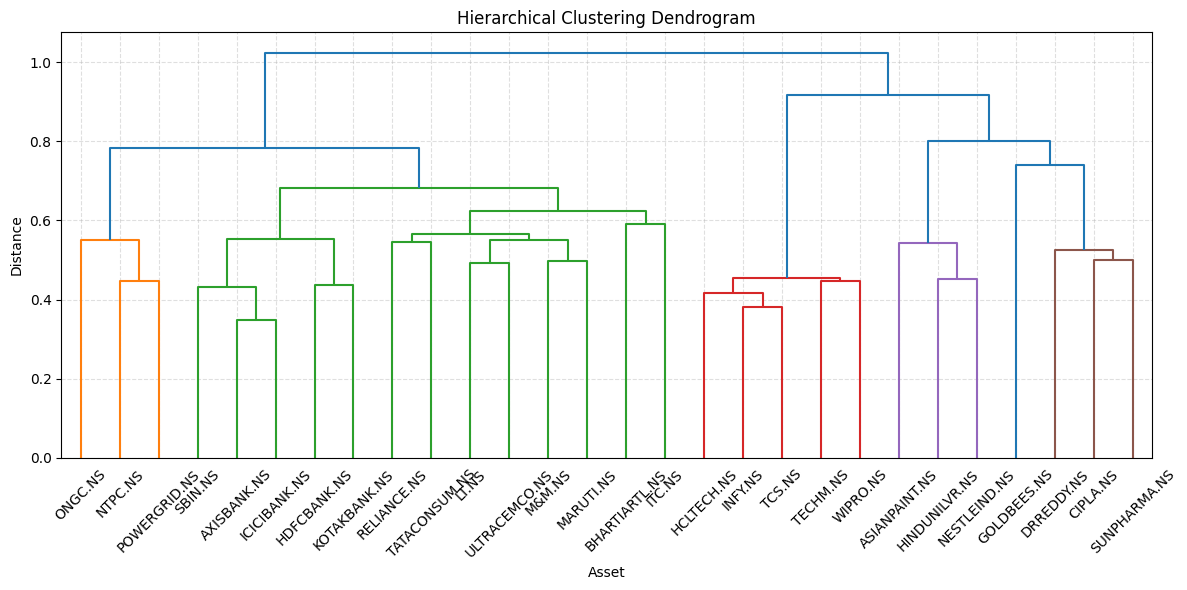

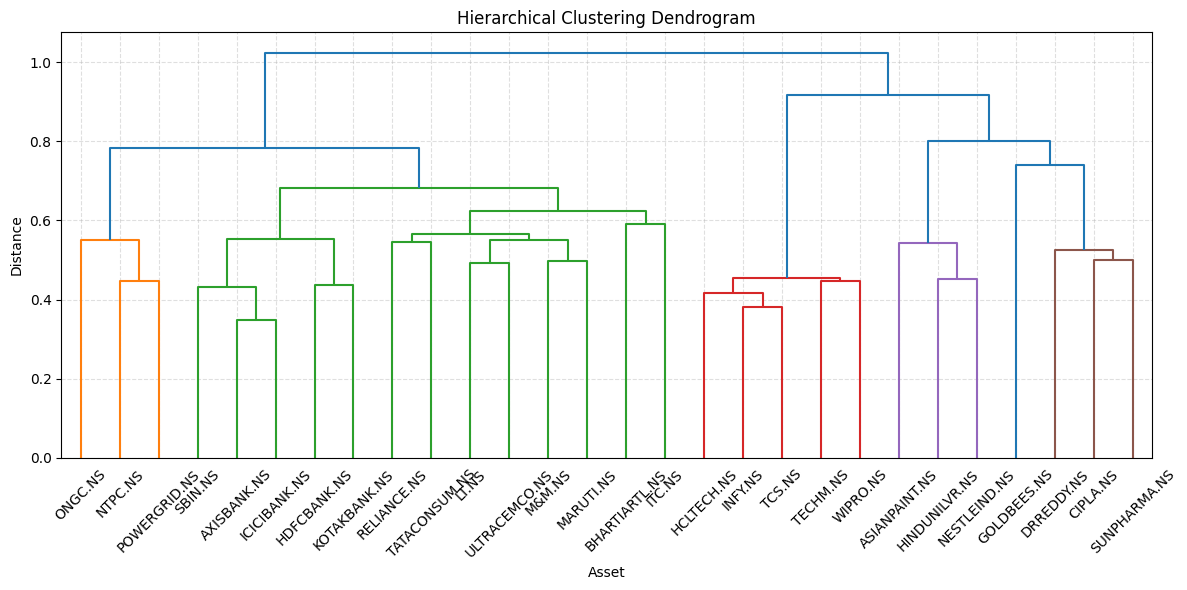

In [5]:
fig_ward = plot_dendrogram(linkage_ward, labels=distance_matrix_df.index.tolist())
fig_ward

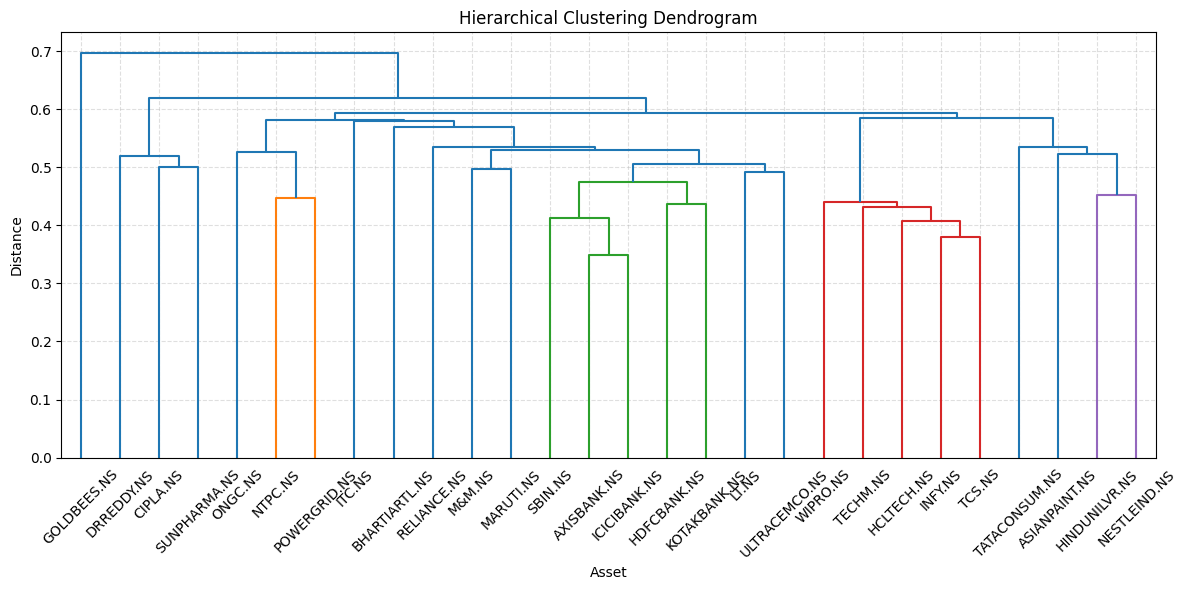

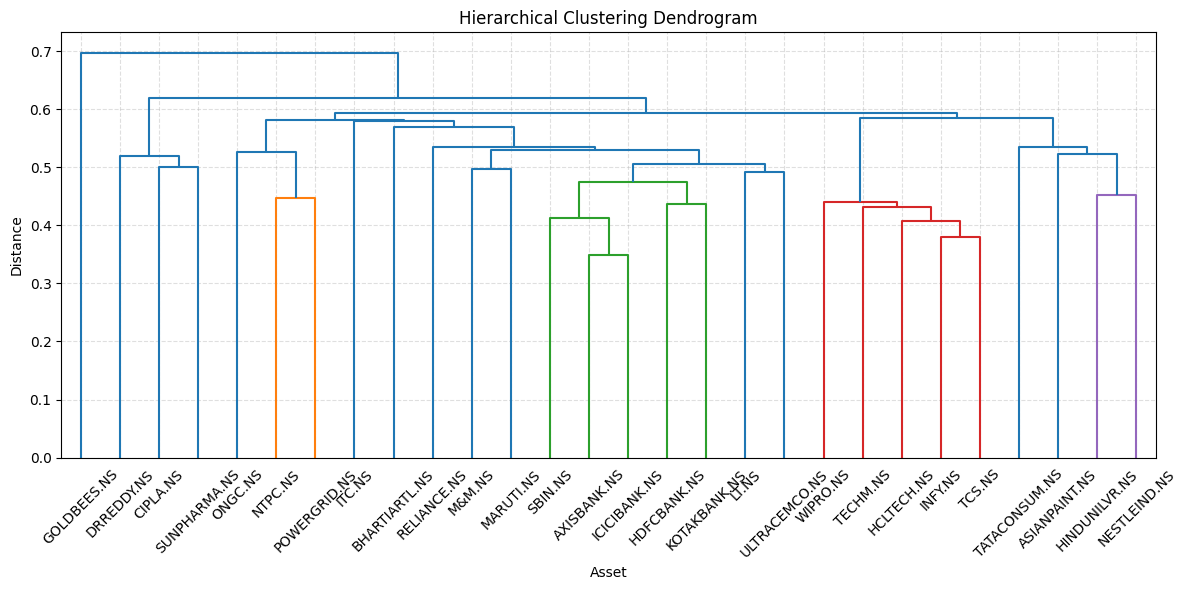

In [6]:
fig_average = plot_dendrogram(linkage_average, labels=distance_matrix_df.index.tolist())
fig_average

## Cluster Assignments

Create cluster assignments and display the resulting membership structure and summary.

In [7]:
n_clusters = 3


#Use ward clustering for the example assignment. The same distance matrix can be assigned with different linkage methods to compare groupings.


cluster_labels = assign_clusters(linkage_ward, n_clusters=n_clusters)
cluster_members = get_cluster_members(distance_matrix_df.index.tolist(), cluster_labels)
cluster_table = pd.DataFrame(
    [(label, asset) for label, members in cluster_members.items() for asset in members],
    columns=["cluster", "asset"],
)
cluster_table

,cluster,asset
0,3,ASIANPAINT.NS
1,3,CIPLA.NS
2,3,DRREDDY.NS
3,3,GOLDBEES.NS
4,3,HINDUNILVR.NS
5,3,NESTLEIND.NS
6,3,SUNPHARMA.NS
7,1,AXISBANK.NS
8,1,BHARTIARTL.NS
9,1,HDFCBANK.NS


In [8]:
cluster_size = cluster_table.groupby("cluster").size().reset_index(name="size")
asset_cluster_map = {asset: int(label) for label, asset in zip(cluster_table["cluster"], cluster_table["asset"])}

display(cluster_size)
asset_cluster_map

,cluster,size
0,1,16
1,2,5
2,3,7


{'ASIANPAINT.NS': 3,
 'CIPLA.NS': 3,
 'DRREDDY.NS': 3,
 'GOLDBEES.NS': 3,
 'HINDUNILVR.NS': 3,
 'NESTLEIND.NS': 3,
 'SUNPHARMA.NS': 3,
 'AXISBANK.NS': 1,
 'BHARTIARTL.NS': 1,
 'HDFCBANK.NS': 1,
 'ICICIBANK.NS': 1,
 'ITC.NS': 1,
 'KOTAKBANK.NS': 1,
 'LT.NS': 1,
 'M&M.NS': 1,
 'MARUTI.NS': 1,
 'NTPC.NS': 1,
 'ONGC.NS': 1,
 'POWERGRID.NS': 1,
 'RELIANCE.NS': 1,
 'SBIN.NS': 1,
 'TATACONSUM.NS': 1,
 'ULTRACEMCO.NS': 1,
 'HCLTECH.NS': 2,
 'INFY.NS': 2,
 'TCS.NS': 2,
 'TECHM.NS': 2,
 'WIPRO.NS': 2}

## Interpretation

- **Correlation vs clustering**: correlation measures pairwise similarity, while clustering discovers groups of assets that form cohesive subsets across the full distance geometry.
- **Hidden structure**: clustering reveals sub-groups not obvious from single pair comparisons.
- **Same cluster**: two assets can share a cluster because their distances to the rest of the universe are similar, even if their direct correlation is not the maximum.
- **HRP readiness**: HRP uses these clusters to reduce concentration and allocate within coherent risk groups before weights are computed.
- **Concentration risk**: clustering groups similar assets, which helps avoid overweighting closely correlated names later in the allocation stage.